# CBD-3333 Assignment 1 — Practical Data Mining
# Student Name: Alejandro Parparcen Grillet
Online Retail dataset. Three tasks: **preprocessing**, **K-Means clustering**, **association rules**.

> **Note from running my notebook:** While testing, keep `SAMPLE_SIZE` small; 
> for a full usage of all the dataset set it to `None` to use all rows. 
> This is to prevent memory issues when running the notebook on a local machine, which i ran into a lot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Testing Toogle
# small number = fast testing.  None = ALL rows (use this for the final run).
SAMPLE_SIZE = None

## Task 1: Data Preprocessing

In [2]:
# load data (only SAMPLE_SIZE rows while testing; None = all rows)
df = pd.read_excel("./online_retail.xlsx", nrows=SAMPLE_SIZE)
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Handle missing values, and drop cancelled / invalid rows.

In [3]:
# missing values per column
print(df.isna().sum())

# CustomerID + Description are needed, so drop rows missing them
df = df.dropna(subset=["CustomerID", "Description"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)

# drop cancelled invoices 'C' 
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# bad rows (returns / zero price)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print("after cleaning:", df.shape)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


after cleaning: (397884, 8)


Convert categorical columns to numbers with one-hot encoding. `.sparse.from_spmatrix` saves memory.

In [4]:
from sklearn.preprocessing import OneHotEncoder

df["StockCode"] = df["StockCode"].astype(str)          

encoder = OneHotEncoder(sparse_output=True)

encoded = encoder.fit_transform(df[["StockCode", "Country"]])
names = encoder.get_feature_names_out(["StockCode", "Country"])

encoded_df = pd.DataFrame.sparse.from_spmatrix(encoded, columns=names, index=df.index)
print(encoded_df.shape, "sparse uses", round(encoded.data.nbytes/1e6, 1), "MB")

del encoded, encoded_df   # not reused downstream; free the sparse matrix (see note below)


(397884, 3702) sparse uses 6.4 MB


> **Note:** we demonstrate one-hot encoding here, but we **don't feed it into K-Means** — 3,700 product columns would dominate the Euclidean distance, so clustering uses the behavioral **RFM** features instead (Task 2). The categorical→numeric encoding the analysis actually relies on is the **basket matrix** in Task 3.

Remove duplicate records.

In [5]:
before = len(df)

df = df.drop_duplicates()

print("removed", before - len(df), "duplicates", df.shape)

removed 5192 duplicates (392692, 8)


New feature: **Total Price = Quantity × UnitPrice**.

In [6]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Normalize the numeric columns (mean 0, std 1).

In [7]:
from sklearn.preprocessing import StandardScaler
num = ["Quantity", "UnitPrice", "TotalPrice"]
df[[c+"_z" for c in num]] = StandardScaler().fit_transform(df[num])
df[[c+"_z" for c in num]].describe().round(2)

,Quantity_z,UnitPrice_z,TotalPrice_z
count,392692.00,392692.00,392692.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-0.07,-0.14,-0.07
25%,-0.06,-0.08,-0.06
50%,-0.04,-0.05,-0.03
75%,-0.01,0.03,-0.01
max,448.67,365.96,541.46


Summary statistics + a few visualizations.

In [8]:
df[["Quantity", "UnitPrice", "TotalPrice"]].describe().round(2)

,Quantity,UnitPrice,TotalPrice
count,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


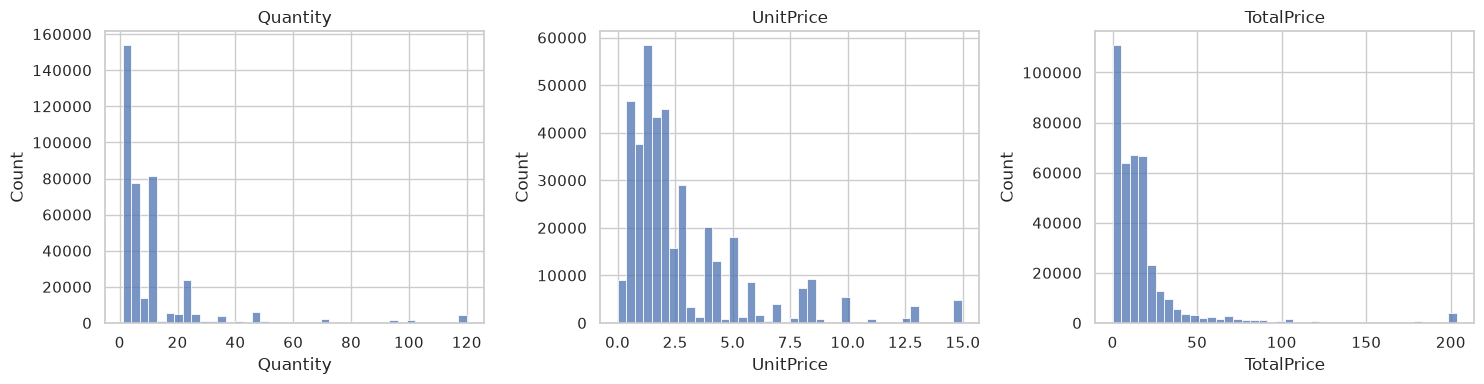

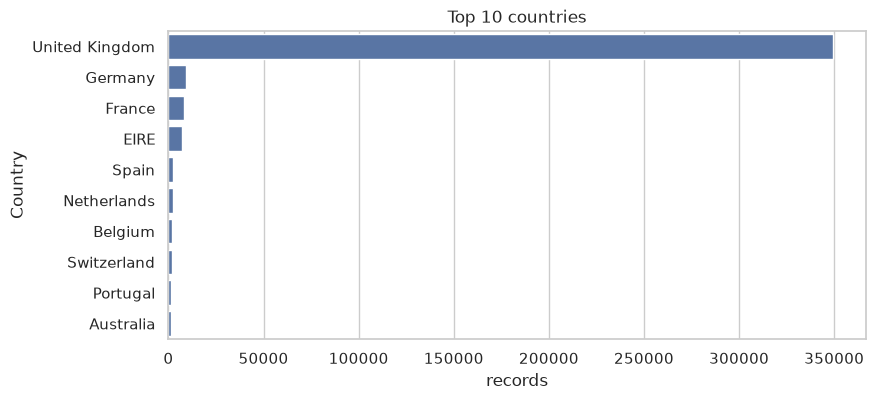

In [9]:
# distributions (clipped at 99th pct so outliers don't squash the plot)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, num):
    sns.histplot(df[c].clip(upper=df[c].quantile(0.99)), bins=40, ax=a)
    a.set_title(c)
plt.tight_layout(); plt.show()

# top 10 countries by number of records
top = df["Country"].value_counts().head(10)
plt.figure(figsize=(9, 4))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 10 countries")
plt.xlabel("records")
plt.show()

## Task 2: Customer Clustering (K-Means)

Build **RFM** features per customer (Recency, Frequency, Monetary). This is the standard way to describe purchase behaviour, and it shrinks 400k+ rows to a few thousand customers.

In [10]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)
rfm = rfm[rfm["Monetary"] > 0]
rfm.describe().round(1)

,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2048.7
std,100.0,7.7,8985.2
min,1.0,1.0,3.8
25%,18.0,1.0,306.5
50%,51.0,2.0,668.6
75%,142.0,5.0,1660.6
max,374.0,209.0,280206.0


Normalize before K-Means. RFM is very skewed, so log first, then standardize.

In [11]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(np.log1p(rfm))

Elbow method — pick `k` where the inertia stops dropping quickly.

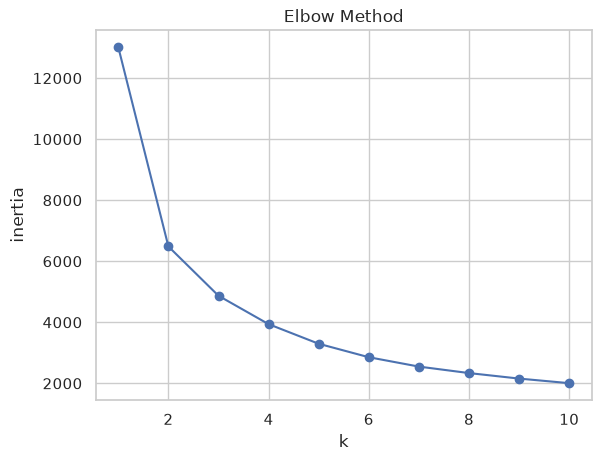

In [12]:
from sklearn.cluster import KMeans
inertia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_ for k in range(1, 11)]
plt.plot(range(1, 11), inertia, "o-"); plt.xlabel("k"); plt.ylabel("inertia")
plt.title("Elbow Method"); plt.show()

Silhouette score — confirm/choose `k` (higher is better).

In [13]:
from sklearn.metrics import silhouette_score
sil = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X))
       for k in range(2, 8)}
best_k = max(sil, key=sil.get)
print({k: round(v, 3) for k, v in sil.items()}, "-> best k =", best_k)

{2: 0.433, 3: 0.337, 4: 0.338, 5: 0.316, 6: 0.312, 7: 0.309} -> best k = 2


Apply K-Means and interpret the clusters (mean RFM per cluster).

In [14]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
rfm["Cluster"] = km.fit_predict(X)
rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"), Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"), Monetary=("Monetary", "mean")).round(1)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,2672,134.1,1.7,495.6
1,1666,25.9,8.4,4539.6


Visualize the segments.

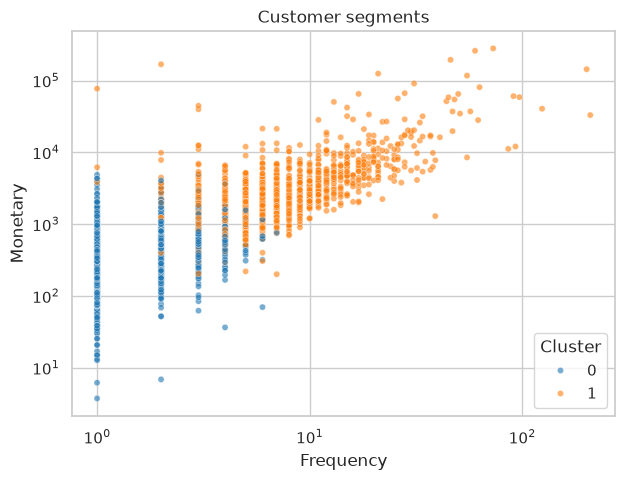

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster",
                palette="tab10", s=20, alpha=0.6)
plt.xscale("log"); plt.yscale("log"); plt.title("Customer segments"); plt.show()

**How businesses use this:** low-Recency + high-Frequency + high-Monetary = best/loyal customers
(reward + retain); high-Recency + low-Frequency = lapsed (win-back offers); recent one-time buyers
get onboarding nudges. Targeting spend per segment beats one-size-fits-all marketing.

## Task 3 — Association Rule Mining (Apriori)

Convert to basket format (one row per invoice, items as columns). Kept **sparse**.

In [16]:
from mlxtend.preprocessing import TransactionEncoder
transactions = df.groupby("InvoiceNo")["Description"].apply(lambda s: list(set(s)))
te = TransactionEncoder()
ary = te.fit_transform(transactions, sparse=True)
basket = pd.DataFrame.sparse.from_spmatrix(ary, columns=te.columns_)
print(basket.shape)

(18532, 3877)


Apriori with the **required** thresholds: min_support = 0.15, min_confidence = 0.5.

In [17]:
from mlxtend.frequent_patterns import apriori, association_rules
freq = apriori(basket, min_support=0.15, use_colnames=True, low_memory=True)
rules = association_rules(freq, metric="confidence", min_threshold=0.5) if len(freq) else pd.DataFrame()
print("itemsets:", len(freq), " rules:", len(rules))

itemsets: 0  rules: 0


0.15 is very strict here (often **0 rules** — no product is in 15% of baskets). To actually see real rules, lower the support on the top-80 products. This stays small and fast.

In [18]:
top_items = df["Description"].value_counts().head(80).index
tx = (df[df["Description"].isin(top_items)]
        .groupby("InvoiceNo")["Description"].apply(lambda s: list(set(s))))
te2 = TransactionEncoder(); ary2 = te2.fit_transform(tx, sparse=True)
basket2 = pd.DataFrame.sparse.from_spmatrix(ary2, columns=te2.columns_)
freq = apriori(basket2, min_support=0.02, use_colnames=True, low_memory=True)
rules = association_rules(freq, metric="confidence", min_threshold=0.5)
print("itemsets:", len(freq), " rules:", len(rules))

itemsets: 142  rules: 37


Top 10 rules by **lift** (lift > 1 = real positive association).

In [19]:
r = rules.sort_values("lift", ascending=False).head(10).copy()
r["antecedents"] = r["antecedents"].apply(lambda s: ", ".join(s))
r["consequents"] = r["consequents"].apply(lambda s: ", ".join(s))
r[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

,antecedents,consequents,support,confidence,lift
33,"ROSES REGENCY TEACUP AND SAUCER , REGENCY CAKE...",GREEN REGENCY TEACUP AND SAUCER,0.021,0.743,15.670
32,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.021,0.834,15.530
11,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.037,0.691,14.575
10,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.037,0.783,14.575
5,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.029,0.602,14.251
6,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.029,0.688,14.251
8,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.032,0.612,14.058
7,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.032,0.729,14.058
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.036,0.672,11.164
3,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.036,0.604,11.164


Bar chart of the most frequent items.

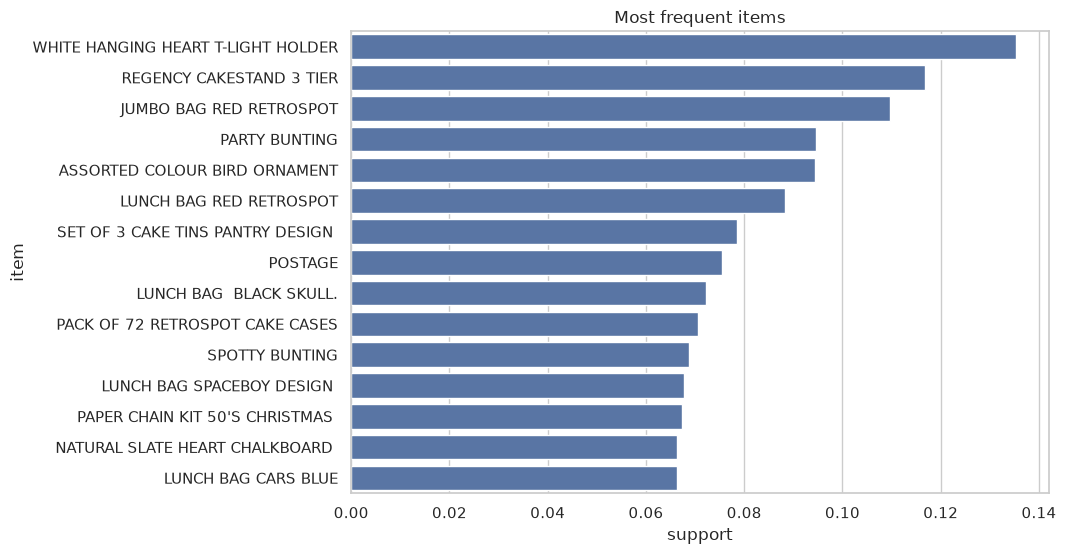

In [20]:
single = freq[freq["itemsets"].apply(len) == 1].copy()
single["item"] = single["itemsets"].apply(lambda s: list(s)[0])
single = single.sort_values("support", ascending=False).head(15)
plt.figure(figsize=(9, 6)); sns.barplot(x=single["support"], y=single["item"])
plt.title("Most frequent items"); plt.xlabel("support"); plt.show()

**Choosing support & confidence (and why not to maximize them):**
- **Support** = how often an itemset appears. Too high → only bestsellers survive, you miss niche patterns. Too low → too many noisy/coincidental itemsets (and it gets slow/memory-heavy).
- **Confidence** = P(consequent | antecedent). High confidence can be *misleading* if the consequent is just popular on its own — that's why we sort by **lift** instead.
- Maximizing both gives a few obvious rules ("milk → bread") with little insight; balancing them surfaces useful co-purchase patterns.

**Business use:** put associated products near each other, build "frequently bought together"
recommendations, and use a high-lift anchor product to pull through its partners in promotions.